In [167]:
### Here we will check if hierarchical clustering helps us better visualise the structure in our data. 
# This helps us show subclusters in our two endotypes

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'PCA of shap ISS>24')

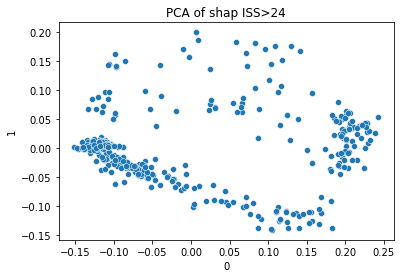

In [314]:
# import data of PCA, pro and clin
pca_df = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/PCA_24.csv', index_col=0)
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

# preprocessing
prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)

# plot the data from the previous analyses
sns.scatterplot(pca_df.iloc[:,0], pca_df.iloc[:,1]).set_title("PCA of shap ISS>24")

/usr/local/anaconda3/envs/phd_paper/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'PCA of shap ISS>24')

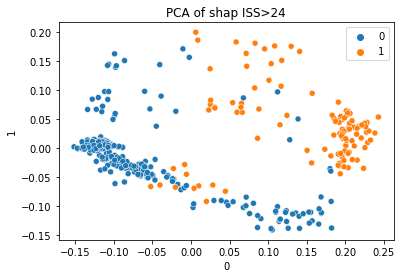

In [353]:
# hierachical clustering on data
shap_values = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/shap_values_24.csv', index_col=0)
linkage_data = linkage(shap_values, method='complete', metric='cityblock')

# hierarchical clustering of shap values 
# identifies two clusters that are very similar to A and B
# we tried with one and two and we got fairly similar clusters to ours (at least the core is kept)

hierarchical_cluster = AgglomerativeClustering(n_clusters=2, affinity='manhattan', linkage='complete')
labels = hierarchical_cluster.fit_predict(shap_values) 
df_idx = pd.DataFrame(labels, index=shap_values.index, columns=['group'])
df_idx['group'] = df_idx.iloc[:,0].replace({0:'group1', 1:'group2'})
sns.scatterplot(pca_df.iloc[:,0], pca_df.iloc[:,1], hue = labels).set_title("PCA of shap ISS>24")

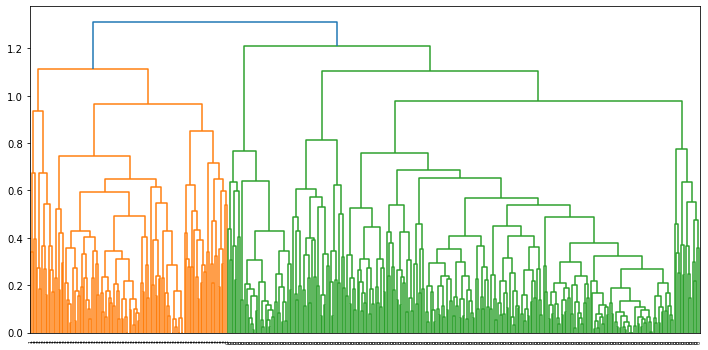

In [358]:
# The two clusters that we get do not match the original clusters
plt.figure(figsize = (12, 6))
a = dendrogram(linkage_data, labels = labels, p = 2, color_threshold=1.3)
plt.show() 

In [359]:
# read top and bottom data
shap_df = pd.DataFrame(pca_df)
shap_df.index = pca_df.index
bottom_left = shap_df[(shap_df.iloc[:,0]<=0.05) & (shap_df.iloc[:,1]<0.03)]
bottom_right = shap_df[(shap_df.iloc[:,0]>=0.05) & (shap_df.iloc[:,1]<-0.05)]
bottom_right.shape
bottom = bottom_left.append(bottom_right)
bottom.shape

# top branch
top_index=[]
for i in shap_df.index:
    if i not in bottom.index:
        top_index.append(i)
top = shap_df.filter(items = top_index, axis = 0)

print(len(top)+len(bottom))
top_all = top.index
bottom_all = bottom.index
all_labels = ['A']*len(bottom_all)+['B']*len(top_all)
endo_labels = pd.Series(all_labels, index = bottom_all.append(top_all))

414


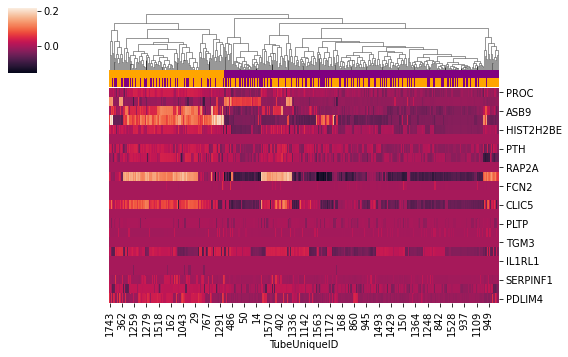

In [351]:
# groups from the clustering
colors = {0:'purple', 1:'orange'}
col_colors = pd.Series(labels, index = shap_values.index).map(colors)

# groups from the endotypes
endo_cols =  {'A':'orange', 'B':'purple'}
endotypes_cols = endo_labels.map(endo_cols)

# groups do not match in this map
sns.clustermap(
    shap_values.T,
    figsize=(8, 5),
    row_cluster=False,
    metric='cityblock', #citiblock
    method = 'complete', # complete 
    col_colors=[col_colors, endotypes_cols]
) 


### Using PCA values rather than real values

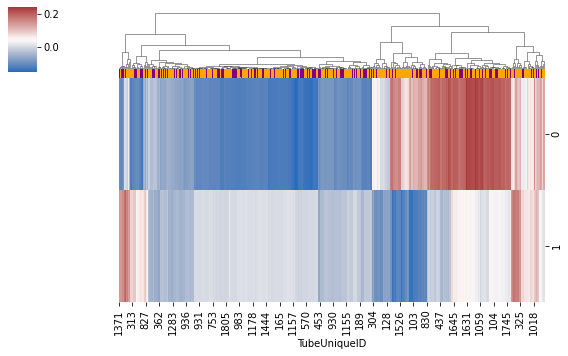

In [360]:
### what if I pass the PCA rather than the actual values
sns.clustermap(
    shap_df.T.iloc[0:2,:],
    figsize=(8, 5),
    row_cluster=False,
    metric='cityblock', #citiblock
    method = 'complete', # complete 
    col_colors=[endotypes_cols], 
    cmap = 'vlag'
)
